# RADS Verification Notebook 02: Verify Dataset

This notebook builds and tests the `VideoFrameDataset` and `create_dataloaders()` factory, extracts and visualizes frames from TUDAT videos, verifies the augmentation pipelines, and logs samples to W&B.


In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import torch

# Ensure project root is in path
project_root = Path("../..").resolve()
sys.path.insert(0, str(project_root))

from training.configs.config import load_training_config
from training.datasets.frame_dataset import VideoFrameDataset
from training.datasets.transforms import get_train_transforms, get_val_transforms
from training.datasets.dataloader import create_dataloaders
from training.utils.wandb_manager import TrainingWandbManager

# Load config
config = load_training_config()
print('Dataset Name:', config.dataset_name)


Dataset Name: tudat


In [2]:
# Instantiate dataset
image_size = config.image_size
train_transforms = get_train_transforms(image_size)

dataset = VideoFrameDataset(
    config=config,
    split='train',
    transform=train_transforms
)

print(f'Dataset length (total sampled frames): {len(dataset)}')
print(f'Class mapping: {dataset.class_mapping}')
print(f'Class names: {dataset.class_names}')
print(f'Class counts: {dataset.class_counts}')
print(f'Class weights: {dataset.class_weights}')


Dataset length (total sampled frames): 385
Class mapping: {'accident': 0, 'non-accident': 1}
Class names: ['accident', 'non-accident']
Class counts: {'accident': 210, 'non-accident': 175}
Class weights: tensor([0.9167, 1.1000])


In [3]:
# Access a sample
frame, label = dataset[0]
print('Frame tensor shape:', frame.shape)
print('Frame tensor min/max:', frame.min().item(), frame.max().item())
print('Label index:', label, f'({dataset.class_names[label]})')


Frame tensor shape: torch.Size([3, 224, 224])
Frame tensor min/max: -1.7582842111587524 1.489673376083374
Label index: 0 (accident)


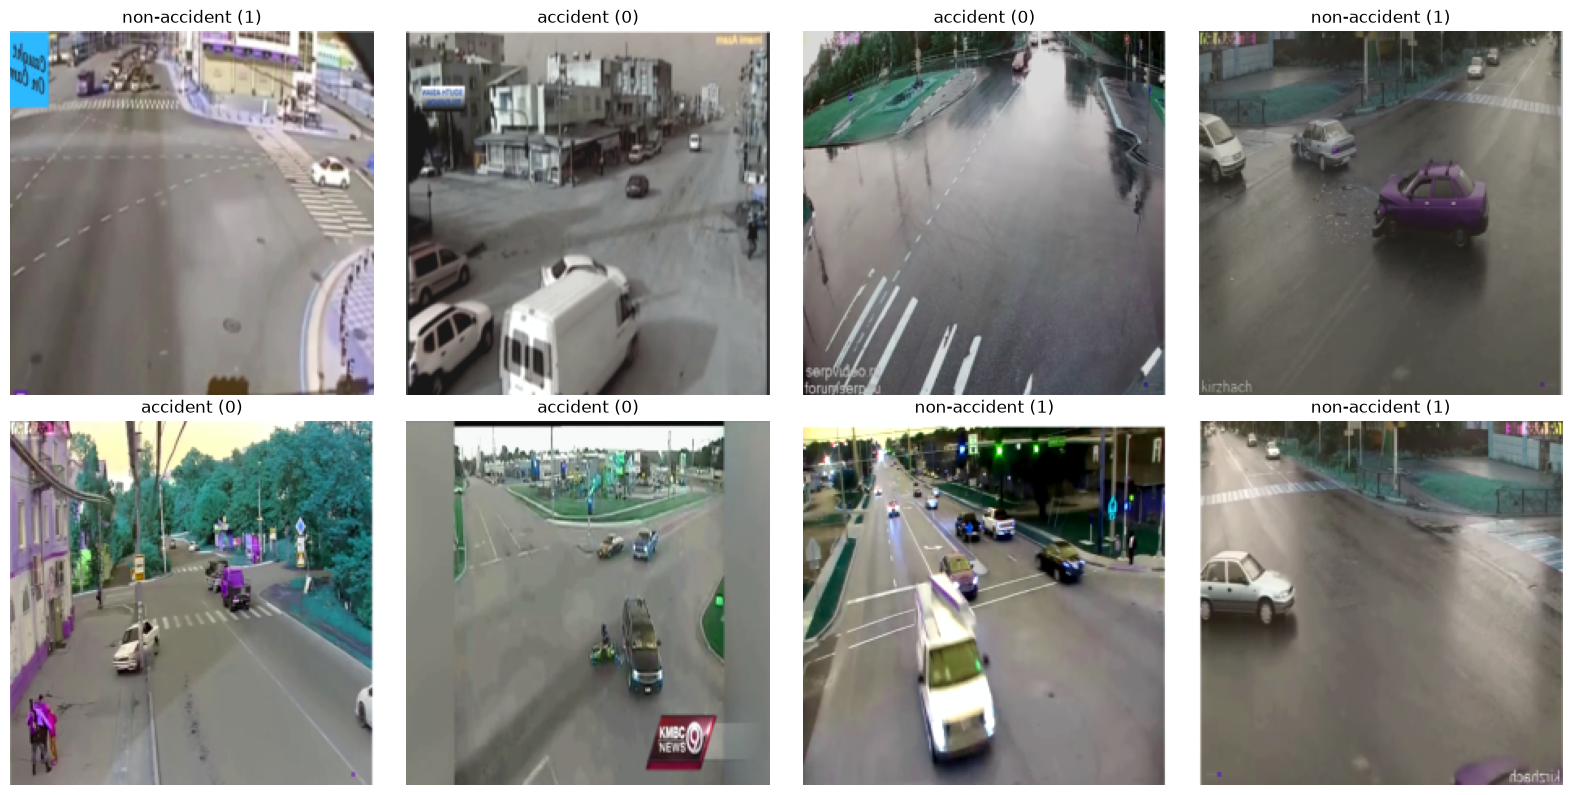

In [5]:
# Visualize random samples (matplotlib grid)
import numpy as np

def denormalize(tensor):
    # ImageNet stats denormalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

indices = np.random.choice(len(dataset), size=8, replace=False)
for idx, ax in zip(indices, axes):
    frame_tensor, label_idx = dataset[idx]
    img = denormalize(frame_tensor)
    class_name = dataset.class_names[label_idx]
    ax.imshow(img)
    ax.set_title(f'{class_name} ({label_idx})')
    ax.axis('off')

plt.tight_layout()
plt.show()


In [6]:
# Test dataloaders
train_loader, val_loader = create_dataloaders(config, use_weighted_sampler=True)

batch_images, batch_labels = next(iter(train_loader))
print(f'Train batch images shape: {batch_images.shape}')
print(f'Train batch labels shape: {batch_labels.shape}')
print(f'Train batch labels: {batch_labels.tolist()}')


Train batch images shape: torch.Size([32, 3, 224, 224])
Train batch labels shape: torch.Size([32])
Train batch labels: [1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0]


In [7]:
# Log sample images to W&B
wb_manager = TrainingWandbManager(config)
with wb_manager:
    # Log the figure to W&B
    wb_manager.log_figure(fig, 'dataset/sample_frames', caption='Randomly sampled and augmented training frames')
    print('Successfully logged sample figure to W&B!')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Amita nagar\_netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Successfully logged sample figure to W&B!
